In [23]:
import glob
import matplotlib.pyplot as plt
import random
from tqdm.auto import tqdm
import cv2
import numpy as np
import os # Added for path joining and checking directories
from sklearn.model_selection import train_test_split # Added for easier train/val split


In [24]:

# --- 1. Load Training Data (Only "good" images) ---
print("Loading training data...")
train_file_paths = glob.glob('cable/train/good/*.png')
# Optional: Sort if needed, though shuffling later makes it less critical
# train_file_paths = sorted([path for path in train_file_paths if path.split('/')[-1] in [f'{i:03}.png' for i in range(224)]]) # Original sorting logic, adjust range if needed

train_images = []
for img_path in tqdm(train_file_paths, desc="Reading train images"):
    img = cv2.imread(img_path)
    if img is not None:
        img = img[..., ::-1] # BGR to RGB
        train_images.append(img)
    else:
        print(f"Warning: Could not read image {img_path}")

if not train_images:
    raise ValueError("No training images loaded. Check the path 'cable/train/good/*.png'")

train_images = np.stack(train_images)
# Assign label 0 to all training images
train_labels = np.zeros(len(train_images), dtype=int)

print(f"Loaded {len(train_images)} training images.")
print(f"Shape of raw training images: {train_images.shape}")


Loading training data...


Reading train images: 100%|██████████| 224/224 [00:03<00:00, 59.77it/s]


Loaded 224 training images.
Shape of raw training images: (224, 1024, 1024, 3)


In [25]:

# --- 2. Split Training Data into Training and Validation Sets ---
# Use sklearn's train_test_split for a robust split
# Split keeping the original numpy array format for now
x_train_raw, x_val_raw, y_train, y_val = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42, shuffle=True
)

# The shape changes from (batch_size, height, width, channels) to (batch_size, channels, height, width)
# Do this *after* splitting
x_train = np.transpose(np.array(x_train_raw), (0, 3, 1, 2))
x_val = np.transpose(np.array(x_val_raw), (0, 3, 1, 2))

print(f'Shape of x_train: {x_train.shape}')
print(f'Shape of x_val: {x_val.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')
print(f'Unique labels in y_train: {np.unique(y_train)}') # Should be [0]
print(f'Unique labels in y_val: {np.unique(y_val)}')   # Should be [0]


# --- (Optional) Visualize some training data ---
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# plt.imshow(x_train_raw[0])
# plt.title(f"Sample Train Image (Label: {y_train[0]})")
# plt.axis('off')
# plt.subplot(1, 2, 2)
# plt.imshow(x_val_raw[0])
# plt.title(f"Sample Validation Image (Label: {y_val[0]})")
# plt.axis('off')
# plt.show()


Shape of x_train: (179, 3, 1024, 1024)
Shape of x_val: (45, 3, 1024, 1024)
Shape of y_train: (179,)
Shape of y_val: (45,)
Unique labels in y_train: [0]
Unique labels in y_val: [0]


In [26]:

# --- 3. Define Transforms and Dataset Class ---
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image

# Define transforms (adjust size as needed for your model)
IMG_SIZE = 224 # Standard for ResNet, change if you use different input size

train_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        # Consider adding more augmentations relevant to your task if needed
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Example
        transforms.RandomRotation(10), # Example
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet normalization
    ]
)

# Validation and Test transforms usually don't include augmentation
val_test_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet normalization
    ]
)

class MVTecDataset(Dataset):
    def __init__(self, x, y, transform=None):
        # x is expected to be (N, C, H, W) numpy array here
        self.x = x
        self.y = torch.from_numpy(y).long() # Labels should be LongTensor for CrossEntropyLoss
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # Transpose C, H, W back to H, W, C for PIL
        img_np = np.transpose(self.x[idx], (1, 2, 0)).astype(np.uint8)
        img_pil = Image.fromarray(img_np)

        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, self.y[idx]


In [27]:

# --- 4. Create DataLoaders for Training and Validation ---
batch_size = 32

train_dataset = MVTecDataset(x_train, y_train, train_transforms)
val_dataset = MVTecDataset(x_val, y_val, val_test_transforms) # Use val_test_transforms

# Consider adding num_workers based on your system capabilities
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

print("Train and Validation DataLoaders created.")


Train and Validation DataLoaders created.


In [28]:

# --- 5. Define the Model (Binary Classification) ---
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

model = models.resnet18(weights='IMAGENET1K_V1') # Or use weights=models.ResNet18_Weights.DEFAULT for newer torchvision

# Freeze parameters initially
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer for BINARY classification (2 outputs: good, defect)
num_ftrs = model.fc.in_features
num_classes_binary = 2 # Class 0: good, Class 1: defect
model.fc = nn.Linear(num_ftrs, num_classes_binary)

# Unfreeze the parameters of the final layer (and potentially others if fine-tuning more)
for param in model.fc.parameters():
    param.requires_grad = True

# Optional: Unfreeze more layers for finer tuning
# for param in model.layer4.parameters():
#      param.requires_grad = True

print(model.fc) # Check the final layer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model moved to {device}")


Linear(in_features=512, out_features=2, bias=True)
Model moved to cuda


In [29]:

# --- 6. Define Loss, Optimizer, and Scheduler ---
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR

criterion = nn.CrossEntropyLoss() # Suitable for multi-class output (2 classes here)

# Optimize only the unfrozen layers (at least the final layer)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
# Example: If you only want to train the fc layer:
# optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# Adjust T_max if you change epochs or loader length
epochs = 20 # Adjust as needed
lr_scheduler = CosineAnnealingLR(optimizer, T_max=len(train_loader)*epochs, eta_min=1e-6) # Adjusted eta_min

print("Optimizer and Scheduler defined.")


Optimizer and Scheduler defined.


In [30]:

# --- 7. Training Loop ---
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
best_val_acc = -1 # Accuracy on validation set (only 'good' images)

print("Starting training...")
for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    total_train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    # Use tqdm for progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for images, labels in train_pbar:
        
        images = images.to(device)
    
        labels = labels.to(device) # Labels are already 0 for all training data
       
        optimizer.zero_grad()
        outputs = model(images)
      
        # Ensure labels are Long
        labels = labels.long()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        lr_scheduler.step() # Step scheduler each batch for CosineAnnealingLR
        total_train_loss += loss.item() * images.size(0) # Accumulate weighted loss

        train_predicted = outputs.argmax(-1)
        train_correct += (train_predicted == labels).sum().item()
        total_train_samples += labels.size(0)
        # Update progress bar
        train_pbar.set_postfix({'loss': loss.item(), 'lr': lr_scheduler.get_last_lr()[0]})

    avg_train_loss = total_train_loss / total_train_samples
    train_accuracy = 100. * train_correct / total_train_samples
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # --- Validation Phase ---
    model.eval()
    total_val_loss = 0.0
    val_correct = 0
    total_val_samples = 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
    with torch.no_grad():
        for images, labels in val_pbar:
            images = images.to(device)
            labels = labels.to(device) # Labels are already 0 for all validation data

            outputs = model(images)
            labels = labels.long()

            loss = criterion(outputs, labels)
            total_val_loss += loss.item() * images.size(0) # Accumulate weighted loss

            predicted = outputs.argmax(-1)
            val_correct += (predicted == labels).sum().item()
            total_val_samples += labels.size(0)
            val_pbar.set_postfix({'loss': loss.item()})


    avg_val_loss = total_val_loss / total_val_samples
    val_accuracy = 100. * val_correct / total_val_samples
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)


    print(f"Epoch {epoch+1}/{epochs} Summary: \n"
          f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% \n"
          f"  Val Loss  : {avg_val_loss:.4f}, Val Acc  : {val_accuracy:.2f}%")


    # Checkpoint saving logic (save based on validation accuracy or loss)
    # Saving based on val accuracy might be more intuitive here
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'model_binary_anomaly.pth')
        print(f"  -> New best model saved with Val Acc: {best_val_acc:.2f}%")
    # Or save based on validation loss:
    # if avg_val_loss < best_val_loss:
    #     best_val_loss = avg_val_loss
    #     torch.save(model.state_dict(), 'model_binary_anomaly.pth')
    #     print(f"  -> New best model saved with Val Loss: {best_val_loss:.4f}")

print("Training finished.")


Starting training...


Epoch 1/20 [Val]: 100%|██████████| 2/2 [00:00<00:00,  6.66it/s, loss=0.00889]


Epoch 1/20 Summary: 
  Train Loss: 0.1358, Train Acc: 98.88% 
  Val Loss  : 0.0085, Val Acc  : 100.00%
  -> New best model saved with Val Acc: 100.00%


Epoch 2/20 [Val]: 100%|██████████| 2/2 [00:00<00:00,  5.82it/s, loss=0.000902]


Epoch 2/20 Summary: 
  Train Loss: 0.0035, Train Acc: 100.00% 
  Val Loss  : 0.0009, Val Acc  : 100.00%


...

Epoch 18/20 Summary: 
  Train Loss: 0.0001, Train Acc: 100.00% 
  Val Loss  : 0.0000, Val Acc  : 100.00%


Epoch 19/20 [Val]: 100%|██████████| 2/2 [00:00<00:00,  5.31it/s, loss=3.66e-5]


Epoch 19/20 Summary: 
  Train Loss: 0.0001, Train Acc: 100.00% 
  Val Loss  : 0.0000, Val Acc  : 100.00%


Epoch 20/20 [Val]: 100%|██████████| 2/2 [00:00<00:00,  6.17it/s, loss=3.84e-5]

Epoch 20/20 Summary: 
  Train Loss: 0.0001, Train Acc: 100.00% 
  Val Loss  : 0.0000, Val Acc  : 100.00%
Training finished.


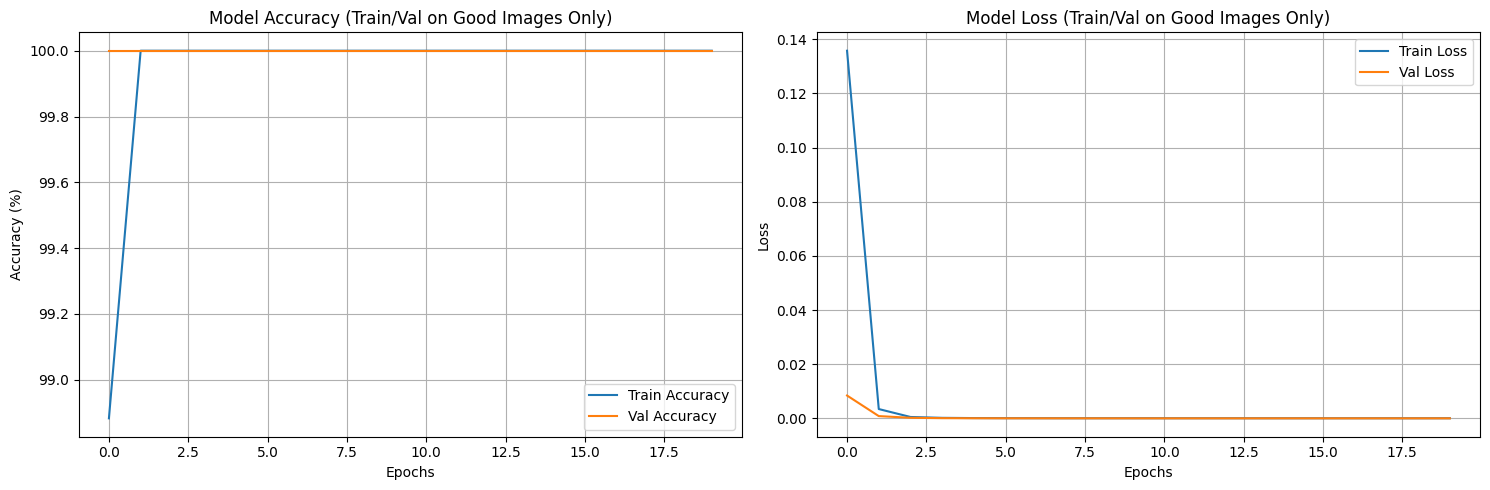

In [31]:

# --- 8. Plot Training History ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plotting training and validation accuracy
ax[0].plot(train_accuracies, label='Train Accuracy')
ax[0].plot(val_accuracies, label='Val Accuracy')
ax[0].set_title('Model Accuracy (Train/Val on Good Images Only)')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy (%)')
ax[0].legend()
ax[0].grid(True)

# Plotting training and validation loss
ax[1].plot(train_losses, label='Train Loss')
ax[1].plot(val_losses, label='Val Loss')
ax[1].set_title('Model Loss (Train/Val on Good Images Only)')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()



In [32]:

# --- 9. Load Test Data (Good and Defect Images) ---
print("\nLoading test data...")
test_dir = 'cable/test/'
test_image_paths = []
test_labels = []

# Find all subdirectories in the test folder
test_subdirs = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]

if not test_subdirs:
     raise FileNotFoundError(f"No subdirectories found in {test_dir}. Ensure 'good' and defect folders exist.")

for subdir in test_subdirs:
    label = 0 if subdir == 'good' else 1 # 0 for good, 1 for defect
    subdir_path = os.path.join(test_dir, subdir)
    image_files = glob.glob(os.path.join(subdir_path, '*.png')) # Adjust pattern if needed
    print(f"  Found {len(image_files)} images in {subdir} (Label: {label})")
    for img_path in image_files:
        test_image_paths.append(img_path)
        test_labels.append(label)

# Load actual image data
test_images = []
valid_test_labels = []
for i, img_path in enumerate(tqdm(test_image_paths, desc="Reading test images")):
     img = cv2.imread(img_path)
     if img is not None:
         img = img[..., ::-1] # BGR to RGB
         test_images.append(img)
         valid_test_labels.append(test_labels[i]) # Keep label corresponding to successfully read image
     else:
        print(f"Warning: Could not read test image {img_path}")


if not test_images:
    raise ValueError("No test images were successfully loaded. Check paths and image integrity.")

x_test_raw = np.stack(test_images)
y_test = np.array(valid_test_labels)

# Transpose for PyTorch format (N, C, H, W)
x_test = np.transpose(x_test_raw, (0, 3, 1, 2))

print(f"Loaded {len(x_test)} test images.")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Test labels distribution: {np.unique(y_test, return_counts=True)}")




Loading test data...
  Found 13 images in bent_wire (Label: 1)
  Found 12 images in cable_swap (Label: 1)
  Found 11 images in combined (Label: 1)
  Found 14 images in cut_inner_insulation (Label: 1)
  Found 10 images in cut_outer_insulation (Label: 1)
  Found 58 images in good (Label: 0)
  Found 12 images in missing_cable (Label: 1)
  Found 10 images in missing_wire (Label: 1)
  Found 10 images in poke_insulation (Label: 1)


Reading test images: 100%|██████████| 150/150 [00:02<00:00, 57.00it/s]


Loaded 150 test images.
Shape of x_test: (150, 3, 1024, 1024)
Shape of y_test: (150,)
Test labels distribution: (array([0, 1]), array([58, 92], dtype=int64))


In [33]:

# --- 10. Create Test DataLoader ---
test_dataset = MVTecDataset(x_test, y_test, val_test_transforms) # Use non-augmenting transforms
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=0) # No shuffle for testing
print("Test DataLoader created.")


Test DataLoader created.


In [34]:

# --- 11. Evaluate on Test Set ---
print("\nEvaluating on the test set...")

# Load the best saved model weights
model.load_state_dict(torch.load('model_binary_anomaly.pth'))
model = model.to(device) # Ensure model is on the correct device
model.eval() # Set the model to evaluation mode

test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    test_eval_pbar = tqdm(test_loader, desc="Evaluating Test Set")
    for images, labels in test_eval_pbar:
        images = images.to(device)
        labels = labels.to(device).long()

        outputs = model(images)
        predicted = outputs.argmax(-1)

        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Optional: Update pbar with running accuracy
        # running_acc = 100. * test_correct / test_total
        # test_eval_pbar.set_postfix({'acc': f'{running_acc:.2f}%'})


test_accuracy = 100. * test_correct / test_total
print(f'\nFinal Test Accuracy: {test_accuracy:.2f}% ({test_correct}/{test_total})')



Evaluating on the test set...


Evaluating Test Set: 100%|██████████| 5/5 [00:01<00:00,  4.07it/s]


Final Test Accuracy: 38.67% (58/150)


c:\Users\qanto\anaconda3\envs\pytorch\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\qanto\anaconda3\envs\pytorch\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\qanto\anaconda3\envs\pytorch\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Classification Report:
              precision    recall  f1-score   support

        good       0.39      1.00      0.56        58
      defect       0.00      0.00      0.00        92

    accuracy                           0.39       150
   macro avg       0.19      0.50      0.28       150
weighted avg       0.15      0.39      0.22       150

Confusion Matrix:


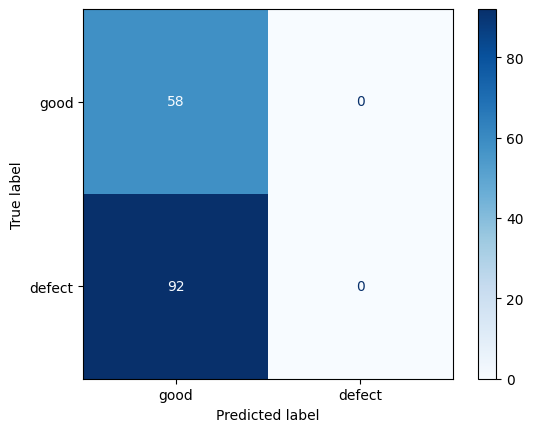

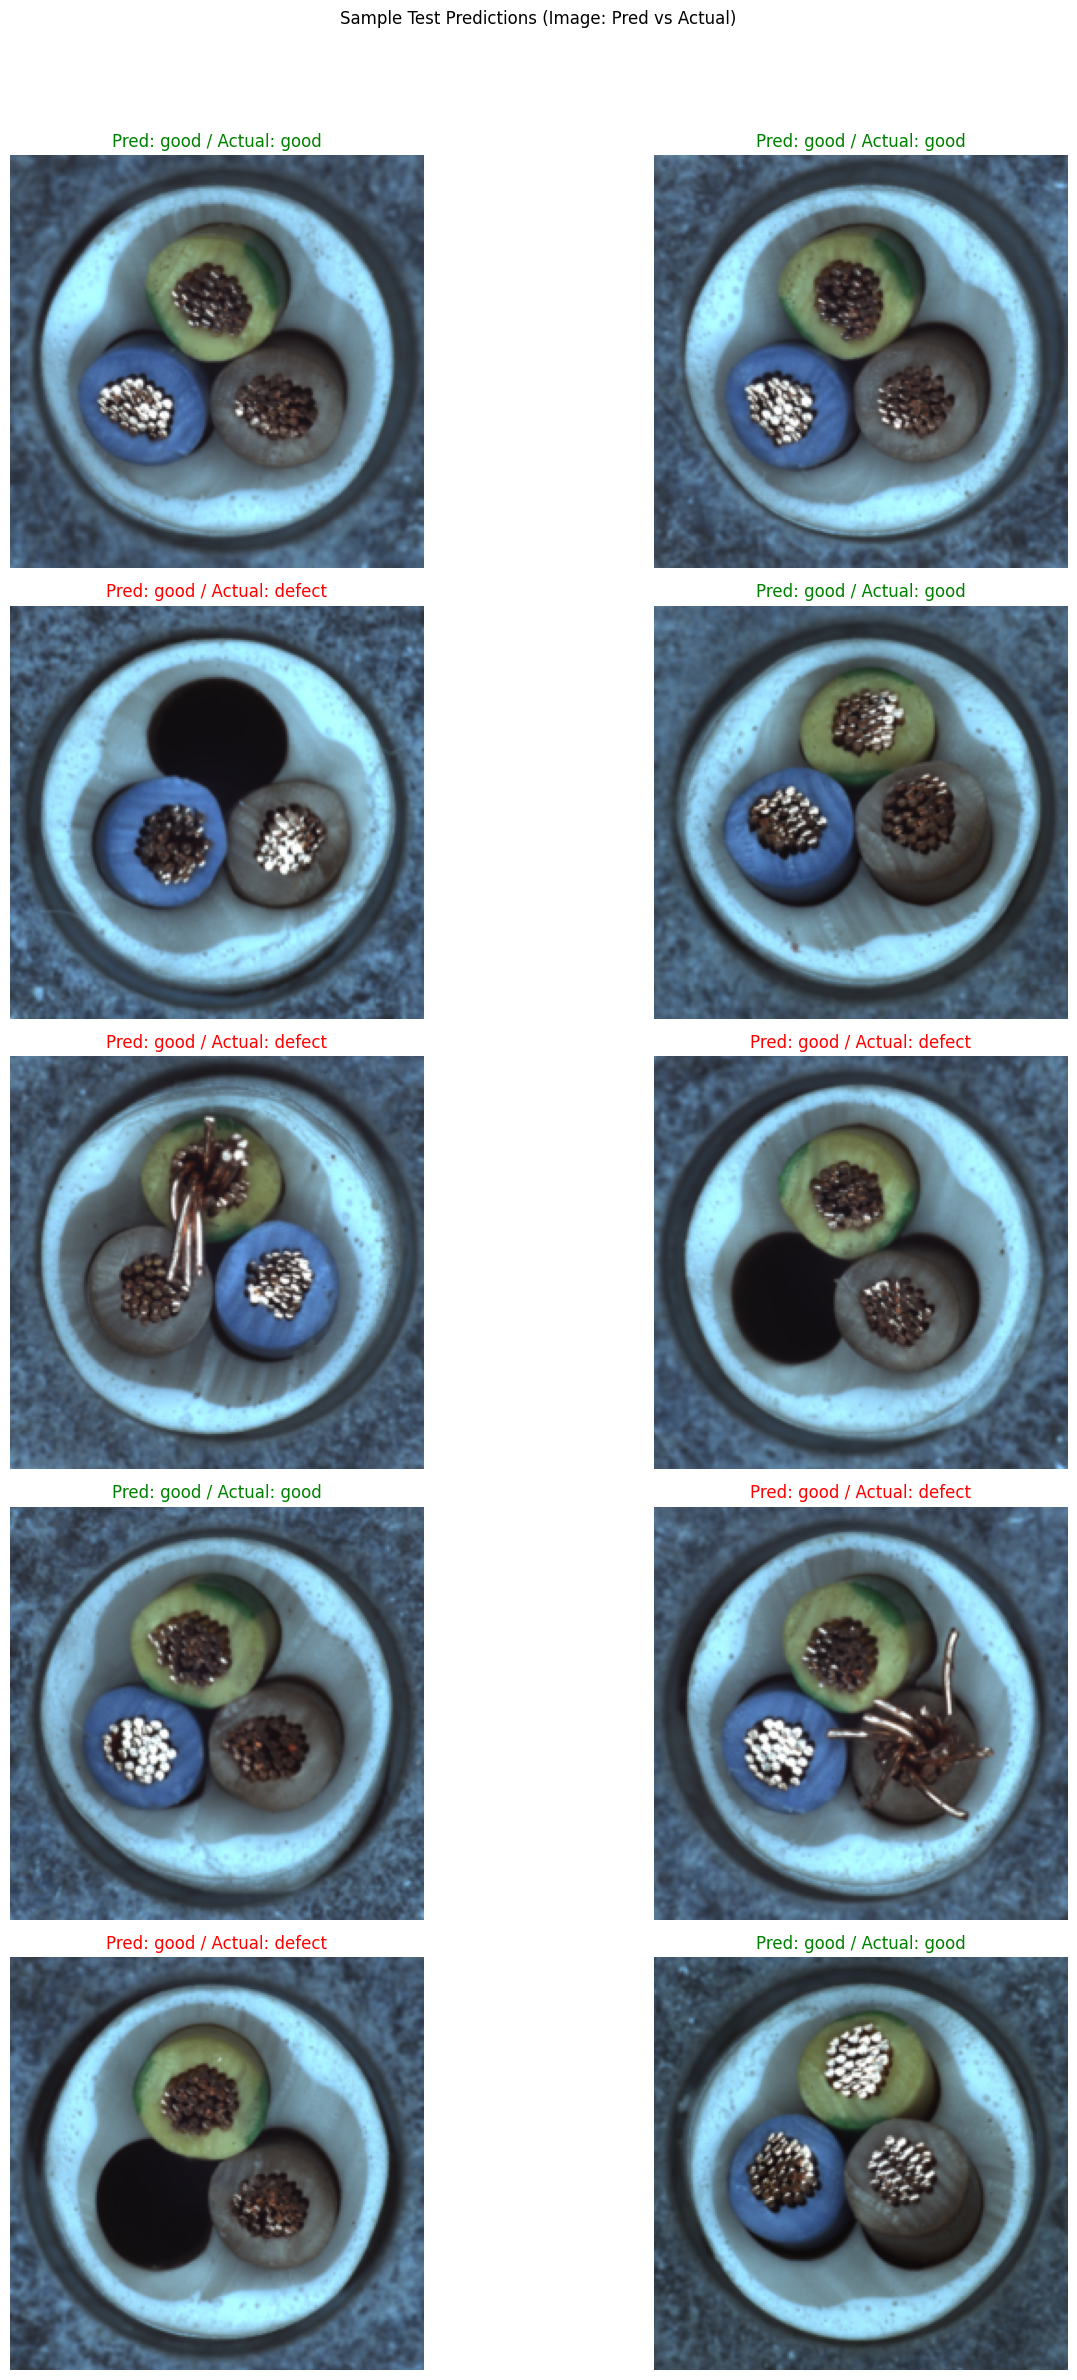

In [35]:

# --- 12. (Optional) More Detailed Evaluation Metrics ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\nClassification Report:")
# Ensure target names match your labels (0: good, 1: defect)
print(classification_report(all_labels, all_preds, target_names=['good', 'defect']))

print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['good', 'defect'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# --- (Optional) Visualize some test predictions ---
num_test_samples_to_show = 10
indices = random.sample(range(len(test_dataset)), min(num_test_samples_to_show, len(test_dataset)))

plt.figure(figsize=(15, 5 * ((len(indices)+1)//2) ))
plt.suptitle("Sample Test Predictions (Image: Pred vs Actual)")

for i, idx in enumerate(indices):
    image, label = test_dataset[idx] # Gets transformed image and label
    image_for_eval = image.unsqueeze(0).to(device) # Add batch dim and move to device

    with torch.no_grad():
        output = model(image_for_eval)
        pred = output.argmax(-1).item()

    # Need to un-normalize and change channel order for display
    inv_normalize = transforms.Normalize(
       mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
       std=[1/0.229, 1/0.224, 1/0.225]
    )
    img_display = inv_normalize(image).permute(1, 2, 0).cpu().numpy()
    img_display = np.clip(img_display, 0, 1) # Clip values to be sure

    ax = plt.subplot(((len(indices)+1)//2), 2, i + 1)
    ax.imshow(img_display)
    ax.set_title(f"Pred: {'defect' if pred==1 else 'good'} / Actual: {'defect' if label==1 else 'good'}",
                 color=("green" if pred == label else "red"))
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()